<img src="../resources/HTLstp-RGB150.png" alt="HTL" width=200>
REFR - Prof. Franz Reichel

DSAI - 4XHIF Klasse

---

# Apfel-vs.-Orange Klassifikation mit dem Fruits-360 Dataset (Kaggle)

Dieses Notebook zeigt ein **einfaches Supervised-Learning-Beispiel mit echten Bildern**  
auf Basis des [Fruits-360 Datasets](https://www.kaggle.com/datasets/moltean/fruits).

Wir machen eine **Binärklassifikation**:

- Klasse **1 = Apfel** (verschiedene Apple-* Klassen)
- Klasse **0 = Orange** (verschiedene Orange-* Klassen)

> 🔧 **Voraussetzung:**  
> Du hast das Fruits-360 Dataset heruntergeladen und lokal entpackt, z. B. in einen Ordner:
>
> ```
> fruits-360/
>   Training/
>   Test/
> ```


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import learning_curve

%matplotlib inline

## 1. Pfade setzen

Passe diesen Pfad an deinen Speicherort des Fruits-360 Datasets an.  
Standard-Annahme: der Ordner `fruits-360/Training` liegt im aktuellen Arbeitsverzeichnis.


In [3]:
# Pfad zum Training-Ordner des Fruits-360 Datasets
base_path = Path("data/fruits-360/Training")

print(base_path.resolve())
if not base_path.exists():
    print("⚠️ Achtung: Der Pfad existiert nicht. Bitte anpassen!")

C:\Users\frank\OneDrive - HTBLuVA St. Pölten\2526\DSAI\refr_dsai_script\notebooks\data\fruits-360\Training


## 2. Apfel- und Orangen-Klassen auswählen

Wir wählen alle Unterordner, deren Name **"Apple"** bzw. **"Orange"** enthält.

Du kannst dir zuerst alle verfügbaren Klassen anzeigen lassen.


In [4]:
# Alle Klassenordner anzeigen
all_class_dirs = [d for d in base_path.iterdir() if d.is_dir()]
print("Anzahl Klassen insgesamt:", len(all_class_dirs))
all_class_dirs[:10]  # erste 10 anzeigen

Anzahl Klassen insgesamt: 4


[WindowsPath('data/fruits-360/Training/Apple 9'),
 WindowsPath('data/fruits-360/Training/Banana 3'),
 WindowsPath('data/fruits-360/Training/Orange 1'),
 WindowsPath('data/fruits-360/Training/Pear 5')]

In [5]:
# Apple- und Orange-Klassen automatisch auswählen
apple_dirs = [d for d in all_class_dirs if "Apple" in d.name]
orange_dirs = [d for d in all_class_dirs if "Orange" in d.name]

print("Gefundene Apple-Klassen:")
for d in apple_dirs:
    print("  -", d.name)

print("\nGefundene Orange-Klassen:")
for d in orange_dirs:
    print("  -", d.name)

Gefundene Apple-Klassen:
  - Apple 9

Gefundene Orange-Klassen:
  - Orange 1


## 3. Bilder laden und in Feature-Vektoren umwandeln

Wir:

- skalieren die Bilder auf **64×64 Pixel**
- wandeln sie in RGB um
- flatten sie zu einem 1D-Feature-Vektor

Um es klein & schnell zu halten, begrenzen wir optional die Anzahl Bilder pro Klasse.


In [6]:
test = [[1,2,3],[4,5,6],[7,8,9]]
print(np.array(test))
print(np.array(test).flatten())



print("*"*30)

img = Image.open("data/fruits-360/Training/Apple 9/r0_3_100.jpg").convert("RGB")
img = img.resize((6,6))
arr = np.array(img)
print(arr)
print(arr.flatten())


[[1 2 3]
 [4 5 6]
 [7 8 9]]
[1 2 3 4 5 6 7 8 9]
******************************
[[[251 250 249]
  [202 180 162]
  [161 132 109]
  [159 143 129]
  [231 228 225]
  [255 255 255]]

 [[216 205 189]
  [169 135 104]
  [123  76  46]
  [ 91  49  25]
  [ 99  70  49]
  [189 180 174]]

 [[184 155 126]
  [135  97  58]
  [ 73  38  19]
  [ 67  31  14]
  [ 60  24   5]
  [117  99  87]]

 [[175 144 125]
  [ 88  45  20]
  [ 39  16   6]
  [ 42  17   6]
  [ 43  17   5]
  [149 142 136]]

 [[221 212 208]
  [ 79  51  38]
  [ 23   7   0]
  [ 26   5   0]
  [ 83  63  54]
  [239 238 238]]

 [[255 255 255]
  [206 203 200]
  [ 94  84  73]
  [100  90  82]
  [218 215 212]
  [255 255 255]]]
[251 250 249 202 180 162 161 132 109 159 143 129 231 228 225 255 255 255
 216 205 189 169 135 104 123  76  46  91  49  25  99  70  49 189 180 174
 184 155 126 135  97  58  73  38  19  67  31  14  60  24   5 117  99  87
 175 144 125  88  45  20  39  16   6  42  17   6  43  17   5 149 142 136
 221 212 208  79  51  38  23   7   0  26 

In [7]:

IMG_SIZE = (64, 64)
MAX_IMAGES_PER_CLASS = 200  # bei Bedarf anpassen oder auf None setzen

def load_image_as_vector(path):
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    arr = np.array(img)
    return arr.flatten()  # z.B. (64*64*3)

X = []
y = []
paths = []

# Helper zum Laden aus mehreren Klassenordnern
def load_from_class_dirs(class_dirs, label):
    count = 0
    for d in class_dirs:
        for p in d.glob("*.jpg"):
            try:
                X.append(load_image_as_vector(p))
                y.append(label)
                paths.append(p)
                count += 1
                if MAX_IMAGES_PER_CLASS is not None and count >= MAX_IMAGES_PER_CLASS:
                    return
            except Exception as e:
                print("Fehler bei", p, ":", e)

# Äpfel = 1
load_from_class_dirs(apple_dirs, label=1)

# Orangen = 0
load_from_class_dirs(orange_dirs, label=0)


X = np.array(X)
y = np.array(y)

print("Anzahl geladener Bilder:", len(X))
print("Feature-Dimension pro Bild:", X.shape[1])

Anzahl geladener Bilder: 360
Feature-Dimension pro Bild: 12288


## 4. Beispielbilder anzeigen

6


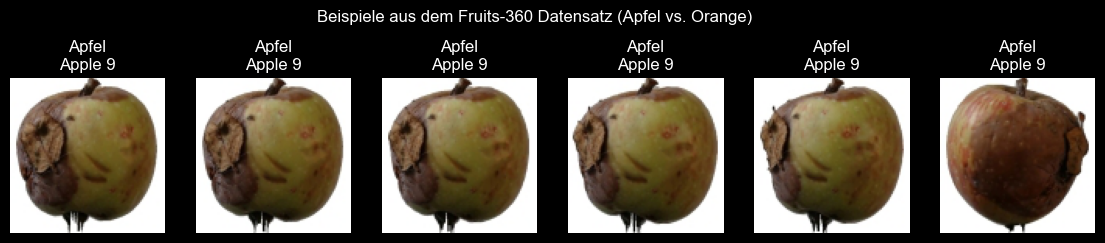

In [8]:
n_show = min(6, len(paths))
print(n_show)
fig, axes = plt.subplots(1, n_show, figsize=(14, 3))
for ax, p, label in zip(axes, paths[:n_show], y[:n_show]):
    img = Image.open(p)
    ax.imshow(img)
    ax.set_title(f"{'Apfel' if label==1 else 'Orange'}\n{p.parent.name}")
    ax.axis("off")

plt.suptitle("Beispiele aus dem Fruits-360 Datensatz (Apfel vs. Orange)")
plt.show()

## 5. Train/Test-Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((288, 12288), (72, 12288))

## 6. Modell trainieren – Logistische Regression

Wir verwenden als sehr einfaches Modell eine **Logistische Regression**.

Hinweis: Für Bilddaten sind eigentlich Convolutional Neural Networks (CNNs) besser geeignet,  
aber hier geht es um ein **didaktisch einfaches Supervised-Learning-Beispiel**.


In [10]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 1.0


## 7. Detaillierter Klassifikationsbericht

In [11]:
print(classification_report(
    y_test, y_pred,
    target_names=["Orange", "Apfel"]
))

              precision    recall  f1-score   support

      Orange       1.00      1.00      1.00        32
       Apfel       1.00      1.00      1.00        40

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



Bedeutung der Spalten

* Precision

    Anteil der korrekt vorhergesagten Elemente einer Klasse an allen Vorhersagen dieser Klasse.

    → „Wenn das Modell Orange sagt, wie oft stimmt das wirklich?“

* Recall

    Anteil der korrekt erkannten Elemente einer Klasse an allen tatsächlich vorhandenen Elementen dieser Klasse.

    → „Wie viele der echten Orangen hat das Modell gefunden?“

* F1-Score

    Harmonisches Mittel aus Precision und Recall.

  → Eine zusammengefasste Kennzahl für die Modellqualität.

* Support

    Anzahl der tatsächlichen Beispiele dieser Klasse im Datensatz.

Interpretation der Werte

* Für Orange:

    * 32 echte Beispiele (support = 32)

    * Precision = 1.00 → alle als Orange vorhergesagten waren korrekt

    * Recall = 1.00 → alle echten Orangen wurden erkannt

* Für Apfel:

    * 40 echte Beispiele

    * ebenfalls perfekte Werte

Gesamtmetriken
* Accuracy = 1.00

→ 100 % aller 72 Beispiele wurden korrekt klassifiziert.


* Macro avg

Durchschnitt der Metriken über alle Klassen ohne Gewichtung.

* Weighted avg

Durchschnitt gewichtet nach der Anzahl der Beispiele pro Klasse.

## 8. Beispiel: Modell-Reasoning auf einem Bild

Wir nehmen ein beliebiges Bild und lassen das Modell eine Vorhersage machen.


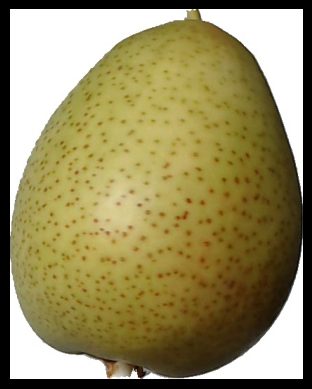

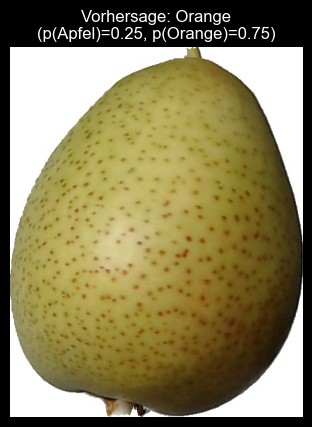

In [13]:
#sample_path = paths[222]
#img = Image.open(paths[222])

sample_path = "data/fruits-360/Testdata/pear.jpg"
#sample_path = "data/fruits-360/Testdata/apple3.jpg"
img = Image.open(sample_path)

plt.imshow(img)
plt.axis("off")
plt.show()

vec = load_image_as_vector(sample_path).reshape(1, -1)
pred = model.predict(vec)[0]
proba = model.predict_proba(vec)[0]

img = Image.open(sample_path)
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Vorhersage: {'Apfel' if pred==1 else 'Orange'}\n"
    f"(p(Apfel)={proba[1]:.2f}, p(Orange)={proba[0]:.2f})"
)
plt.show()

## 9. Fazit

In diesem Notebook haben wir gesehen:

- Wie man **echte Bilder** aus dem Fruits-360 Kaggle-Datensatz lädt  
- Wie man sie aufbereitet und in einfache Feature-Vektoren umwandelt  
- Wie man ein **Supervised-Learning-Modell (Logistische Regression)** trainiert  
- Wie man **Apfel vs. Orange** klassifizieren kann  

Für ernsthafte Bildklassifikation würde man typischerweise:

- ein **CNN** (z. B. mit TensorFlow oder PyTorch) verwenden  
- mit **Data Augmentation** arbeiten  
- mehrere Klassen gleichzeitig klassifizieren  

Trotzdem eignet sich dieses Beispiel sehr gut, um die Grundidee von **Supervised Learning mit Bildern** anschaulich zu demonstrieren.


In [50]:
print("y Typ:", type(y))
print("y erste 20 Werte:", y[:20])
print("y unique:", np.unique(y, return_counts=True))


y Typ: <class 'numpy.ndarray'>
y erste 20 Werte: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
y unique: (array([0, 1]), array([160, 200]))


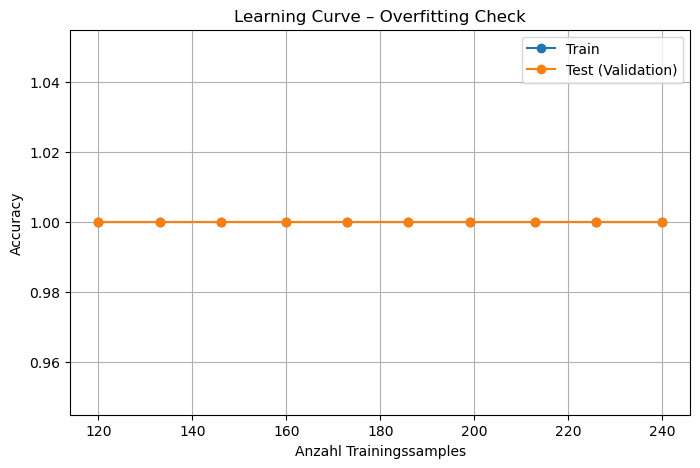

In [51]:
from sklearn.utils import shuffle

X_shuffled, y_shuffled = shuffle(X, y, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    model, X_shuffled, y_shuffled,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.5, 1.0, 10)
)

# train_sizes, train_scores, test_scores = learning_curve(
#     model, X, y, cv=5, scoring="accuracy", random_state=42, train_sizes=np.linspace(0.3, 1.0, 10)
# )

train_mean = train_scores.mean(axis=1)
test_mean  = test_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label="Train", marker="o")
plt.plot(train_sizes, test_mean,  label="Test (Validation)", marker="o")
plt.xlabel("Anzahl Trainingssamples")
plt.ylabel("Accuracy")
plt.title("Learning Curve – Overfitting Check")
plt.legend()
plt.grid(True)
plt.show()